In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd ..

/Users/leonmac/Codes/BO-Set


In [3]:
import torch
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib as mpl
import os
import pickle
import random
import multiprocess

from scipy.stats import spearmanr
from tqdm._tqdm import tqdm
from sklearn import preprocessing
from itertools import product
from math import comb
from functools import partial

from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from publib import set_style, fix_style

from problems.underlying_problem import get_synthetic_problem
from search.trust_region import restart
from search.utils import eigendecompose_laplacian
from search.models import initialize_model
from search.self_combograph import ComboSubgraph_Constructor
import utils.config_utils as config_utils

set_style('article') 
#plt.rcParams['text.usetex'] = True

save_path = 'experiment_figs/Supporting/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

np.random.seed(0)
title_font=38
my_font=25
tick_size=23

/var/folders/0p/p2rtjxnd3hgc3cf2jvwg_1fm0000gn/T/ipykernel_63713/4177975384.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.std.*` instead of `tqdm._tqdm.*`
  from tqdm._tqdm import tqdm


In [4]:
### Define graph
def underlying_graph(config):
    # graph_type = grid, ba, ws
    problem = get_synthetic_problem(
        label=config["problem_name"], 
        seed=0,
        problem_kwargs=config["problem_settings"])
    return problem

def initialize(Graph):
    X_train = torch.empty(0,1)
    Y_train = torch.empty(0,1)
    base_model, base_mll, based_cached_eigenbasis = initialize_model(
                    train_X=X_train,
                    train_Y=Y_train,
                    context_graph=Graph,
                    covar_type="diffusion",
                    covar_kwargs = {"order": 1},
                    fit_model=False,
                    ard=True,
                    use_fixed_noise=False,
                    use_saas_map=False)
    pos = nx.kamada_kawai_layout(Graph)
    return base_model, pos # base_mll, based_cached_eigenbasis

# Find the neighbours of a given ComboNode derived from the underlying Graph
def NeighbourFinder(Graph, ComboNode): # Output edges connected to this ComboNode
    neighbours = np.empty(shape=(0,len(ComboNode)),dtype=int) # Initialise an empty neighbour np.array
    for idx, i in enumerate(ComboNode):
        ComboNode_list = np.delete(ComboNode,idx) # Get the elements except i
        # Find node i's neighbours in the original graph excluding nodes from ComboNode_list
        i_original_neighbours = np.array([j for j in list(Graph.neighbors(i)) if j not in ComboNode_list])
        # Construct the combinatorial nodes for node i
        i_combo_neighbours = np.array(list(map(lambda x : np.append(ComboNode_list, x), i_original_neighbours)))
        if len(i_combo_neighbours)!=0: # stack the neighbours if it is not none
            i_combo_neighbours.sort(axis=1) # sort the array to create a unique identifier for each combo node
            neighbours = np.vstack((neighbours, i_combo_neighbours))
    # Construct the edges from this ComboNode to its neighbours
    stack = np.repeat(np.array(ComboNode).reshape(1,-1),len(neighbours),axis=0)
    edge_array = np.stack((neighbours, stack),axis=1)
    edges = list(tuple(map(tuple, i)) for i in edge_array) # Convert np.array to list of tuples
    return edges

# Find the ComboSubgraph of size Q centred at a given ComboNode by gradually including multi-hops of neighbours
# Initialise the Combo_Subgraph as nx.Graph() and ComboNode_list as [ComboNode] at beginning 
def ComboSubgraph_Constructor(Graph, ComboSubgraph, ComboNode_list, Q=200, l=1): 
    previous_ComboSubgraph_set = set(ComboSubgraph.nodes())
    for ComboNode in ComboNode_list: # add new neighbours of the previous neighbours to the previous ComboSubgraph
        ComboSubgraph.add_edges_from(NeighbourFinder(Graph, ComboNode))
    new_neighbours = list(set(ComboSubgraph.nodes()) - previous_ComboSubgraph_set)
    #print(f"new neighbours at hop {l}: {new_neighbours}")
    if ComboSubgraph.number_of_nodes()<=Q and len(new_neighbours)>0: # do a recursive operation if ComboSubgraph's size < Q
        # Here we set all the neighbours at the current hop as the ComboNode_list for next step
        return ComboSubgraph_Constructor(Graph, ComboSubgraph, new_neighbours, Q, l+1)
    else: # randomly remove a subset of neighbours at the current hop to reach Q 
        nodes_to_remove = random.sample(new_neighbours, 
                                        k=ComboSubgraph.number_of_nodes()-Q)
        ComboSubgraph.remove_nodes_from(nodes_to_remove)
        return ComboSubgraph


In [5]:
def eigendecomp(graph):
    #Laplacian = nx.laplacian_matrix(graph).toarray().astype(np.float32)
    Laplacian = nx.normalized_laplacian_matrix(graph).toarray().astype(np.float32)
    eigenvals, eigenvecs = np.linalg.eigh(Laplacian)
    return eigenvals, eigenvecs

In [6]:
yaml_path = 'configurations/signal_demo.yaml'
config = config_utils.setup(yaml_path)
pb_kwargs = config["problem_settings"]

k, Q = config["problem_settings"]["k"], config["bo_settings"]["Q"]
problem = underlying_graph(config)

path_problem = f'{pb_kwargs["graph_type"]}_{pb_kwargs["underlying_function"]}_m-{pb_kwargs["m"]}_n-{pb_kwargs["n"]}'
path_setting = f"Q-{Q}_k-{k}"
log_path = os.path.join(save_path, f"logs/{path_problem}/{path_setting}")
if not os.path.exists(log_path):
    os.makedirs(log_path)

def get_signal_smoothness(problem,k,Q,idx=None):
    
    # I put the path chunck here for later parallel computing
    path_problem = f'{pb_kwargs["graph_type"]}_{pb_kwargs["underlying_function"]}_m-{pb_kwargs["m"]}_n-{pb_kwargs["n"]}'
    path_setting = f"Q-{Q}_k-{k}"
    log_path = os.path.join(save_path, f"logs/{path_problem}/{path_setting}")
    if not os.path.exists(log_path):
        os.makedirs(log_path)
    
    random.seed(0 if idx is None else idx)
    ComboNode = random.sample(list(problem.underlying_graph.nodes), k) # Sample a random ComboNode as ComboSubgraph centre
    ComboNode.sort() # Very important to sort the ComboNode!
    ComboNode = tuple(ComboNode)
    ComboSubgraph = ComboSubgraph_Constructor(problem.underlying_graph, [ComboNode], nx.Graph(), Q=Q)
    eigenvals, eigenvecs = eigendecomp(ComboSubgraph)
    func_values = problem.evaluate_true( torch.tensor(list(ComboSubgraph.nodes)) ).numpy().squeeze()
    Fourier_Coef = abs(eigenvecs.T@func_values) # in abs
    Fourier_Coef_Squared = Fourier_Coef**2
    if idx is None:
        print(f"Number of all possible ComboNodes: {comb(problem.underlying_graph.number_of_nodes(), k):.2E}")
        print("ComboNode for the ComboSubgraph Centre:", ComboNode)
        return eigenvals, eigenvecs, func_values, Fourier_Coef, np.cumsum(Fourier_Coef_Squared)/sum(Fourier_Coef_Squared)
    else:
        print(f"seed {idx} for k={k} finished!")
        ret = np.cumsum(Fourier_Coef_Squared)/sum(Fourier_Coef_Squared)
        with open(os.path.join(log_path, f"{str(idx).zfill(3)}.npy"), "wb") as f:
            np.save(f, ret)
        return ret

Using BA network (n=1000 m=3) with eigenvector_centrality
feature_computation...........


In [7]:
eigenvals, eigenvecs, func_values, Fourier_Coef, NormCumSq_FC = get_signal_smoothness(problem,k,Q)

number of new neighbors at hop 1: 41
number of new neighbors at hop 2: 1220
Number of all possible ComboNodes: 2.41E+19
ComboNode for the ComboSubgraph Centre: (41, 265, 394, 430, 776, 864, 911, 988)


In [8]:
k_list = [2,4,8,16,32,64]

In [9]:
for k in k_list:
    parallel_func = partial(get_signal_smoothness, problem,k,Q)
    results = np.array(list(map(parallel_func, range(50))))

number of new neighbors at hop 1: 7
number of new neighbors at hop 2: 63
number of new neighbors at hop 3: 573
number of new neighbors at hop 4: 3013
seed 0 for k=2 finished!
number of new neighbors at hop 1: 8
number of new neighbors at hop 2: 271
number of new neighbors at hop 3: 2133
seed 1 for k=2 finished!
number of new neighbors at hop 1: 6
number of new neighbors at hop 2: 83
number of new neighbors at hop 3: 714
number of new neighbors at hop 4: 3739


KeyboardInterrupt: 

In [10]:
color_map = sns.color_palette("flare")

In [11]:
color_map

[(0.9155979, 0.55210684, 0.42070204),
 (0.888292, 0.40830288, 0.36223756),
 (0.81942908, 0.28911553, 0.38102921),
 (0.69226314, 0.23413578, 0.42480327),
 (0.56041794, 0.19845221, 0.44207535),
 (0.42355299, 0.16934709, 0.42581586)]

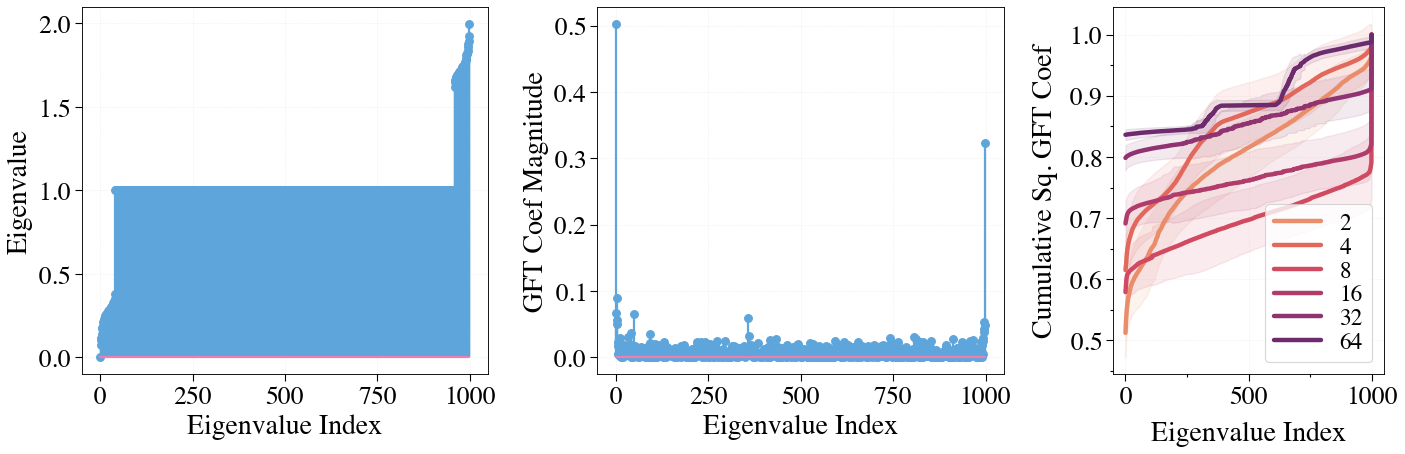

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1.5, 1.5, 1.]})

ax[0].stem(eigenvals)
ax[0].set_ylabel('Eigenvalue', fontsize=my_font)
ax[0].set_xlabel('Eigenvalue Index',fontsize=my_font)
ax[0].tick_params(axis='both', labelsize=tick_size)

ax[1].stem(Fourier_Coef)
#ax[1].set_yscale("log")
ax[1].set_ylabel('GFT Coef Magnitude', fontsize=my_font)
ax[1].set_xlabel('Eigenvalue Index',fontsize=my_font)
ax[1].tick_params(axis='both', labelsize=tick_size)

for idx,k in enumerate(k_list):
    data_path = f"{save_path}logs/{path_problem}/Q-{Q}_k-{k}/"
    seed_list=os.listdir(data_path)
    results=[]
    for i in seed_list:
        with open(data_path+i, 'rb') as f:
            result = np.load(f)
        results.append(result)
    results = np.array(results)
    x = np.arange(results.shape[1])
    mean = np.mean(results, axis=0)
    # standard error
    lb = mean - results.std(axis=0)
    ub = mean + results.std(axis=0)
    
    ax[2].plot(x, mean, "-", label=k, color=color_map[idx], linewidth=4)
    ax[2].fill_between(x,lb, ub, alpha=0.1, color=color_map[idx],)
    ax[2].plot(x, lb, "-", alpha=0.2, color=color_map[idx], linewidth=0.1)
    ax[2].plot(x, ub, "-", alpha=0.2, color=color_map[idx], linewidth=0.1)
    
    ax[2].set_ylabel('Cumulative Sq. GFT Coef', fontsize=my_font)
    ax[2].set_xlabel('Eigenvalue Index',fontsize=my_font)
    ax[2].tick_params(axis='both', labelsize=tick_size)
    ax[2].legend(frameon=True, fontsize=tick_size-2)


fix_style('article')

save_dir = f'./experiment_figs/Supporting/logs/{path_problem}'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
plt.savefig(f"{save_dir}/signal_smoothness_demo.pdf", bbox_inches='tight')
plt.savefig(f"{save_dir}/signal_smoothness_demo.png", bbox_inches='tight')
plt.savefig(f"{save_dir}/signal_smoothness_demo.jpg", bbox_inches='tight')

plt.show()

## BA

def plot_signal_frequency(ax, i, label, feature_name, n=n, m=m):
    base_problem, pos =  output_graph(label, graph, n=n, m=m, feature_name=feature_name)
    eigenvals, eigenvecs, normalized_signal = eigendecomp(base_problem)

    print(normalized_signal[:3])
    amplitudes = np.sqrt( (eigenvecs.T @ normalized_signal)**2 ) # in abs
    amplitudes[ amplitudes < 1e-6] = 0 # make the small values 0
    
    ax[i].scatter(x = range(len(amplitudes)), y = amplitudes )
    ax[i].tick_params(axis='both', labelsize=tick_size)
    if i == 0:
        ax[i].set_ylabel('Amplitude', fontsize=my_font)
    ax[i].set_yscale("log")
    ax[i].set_ylim(1e-3, 1e1)

    ax[i].set_title(f'{graph} {model}', fontsize=title_font)

fig, ax = plt.subplots(1, 4, layout='constrained', figsize=(23, 5))

ax_list = [ax]
label = ["centrality"]
graphs = ["ba"]
feature_name = ["betweenness", "eigenvector_centrality"]
ba_m = [1,2,3,4]
input_data = list(product(ax_list, label, feature_name, n, ba_m, graphs))

ax_list = []
for i in range(4):
    ax_list.append(tuple([i]))
for k in range(4):
    input_data[k] += (ax_list[k])
print(input_data)
for idx in range(len(input_data)):
    plot_signal_frequency(*input_data[idx])

fix_style('article')
save_path = f'./experiment_figs/SignalSmoothness/'
if not os.path.exists(save_path):
    os.makedirs(save_path)
plt.savefig(f"{save_path}{label[0]}_{feature_name[0]}.pdf", bbox_inches='tight')
plt.savefig(f"{save_path}{label[0]}_{feature_name[0]}.png", bbox_inches='tight')
plt.show()